In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.integrate import solve_ivp

colours = cm.inferno(np.linspace(0, 0.9, 10))

In [2]:
from q2_functions import get_derivatives

In [3]:
# Solving the ODE for part 2
W0 = (0, 1, 0)
data = solve_ivp(get_derivatives, t_span=[0,60], y0=W0, dense_output=True)
print(data)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.990e-05 ...  5.996e+01  6.000e+01]
        y: [[ 0.000e+00  9.985e-04 ...  1.066e+01  1.128e+01]
            [ 1.000e+00  9.999e-01 ...  1.281e+01  1.211e+01]
            [ 0.000e+00  4.987e-08 ...  2.714e+01  2.964e+01]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x10e4fe270>
 t_events: None
 y_events: None
     nfev: 5750
     njev: 0
      nlu: 0


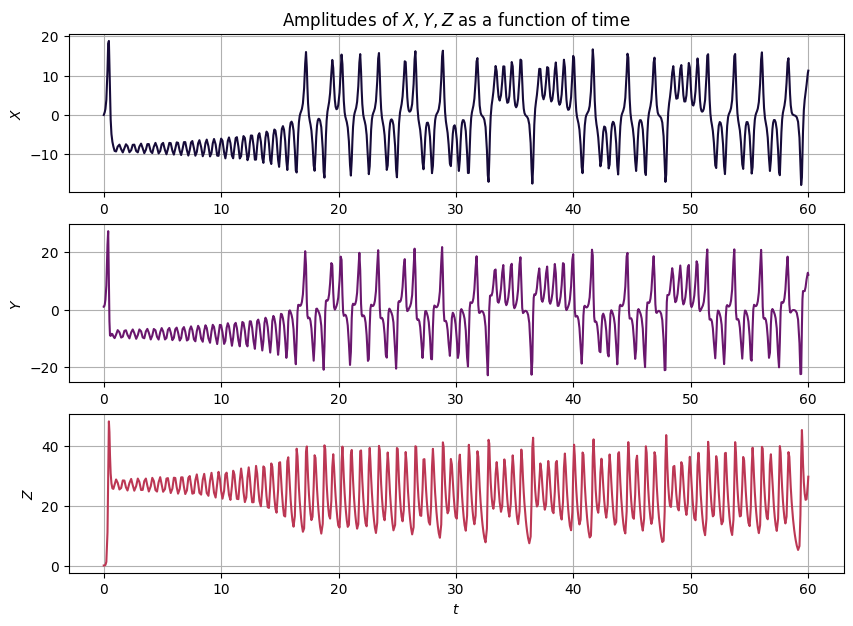

In [4]:
# part 3

fig, ax = plt.subplots(3, 1, dpi=100, figsize=(10, 7))

ax[0].plot(data.t, data.y[0], c=colours[1])

ax[1].plot(data.t, data.y[1], c=colours[3])

ax[2].plot(data.t, data.y[2], c=colours[5])

ax[0].set_ylabel(r"$X$")
ax[0].set_title(r'Amplitudes of $X,Y,Z$ as a function of time')
ax[1].set_ylabel(r"$Y$")
ax[2].set_ylabel(r"$Z$")
ax[2].set_xlabel(r"$t$")
ax[0].grid()
ax[1].grid()
ax[2].grid()

plt.show()

Lorenz' figure 1 is the middle graph, with y-axis labelled $Y$. I will use timesteps to extract Lorenz' figure exactly.

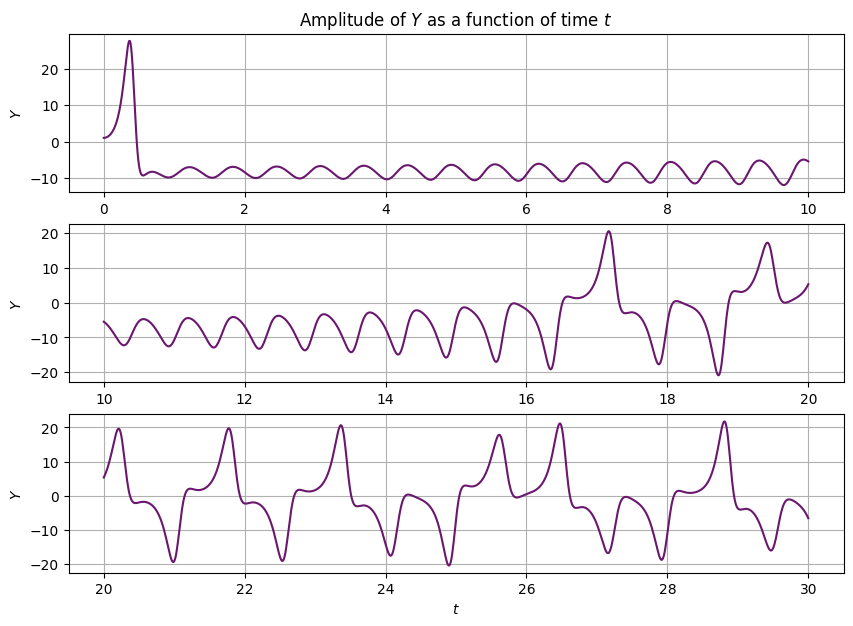

In [5]:
# Part 3
t3_1 = np.linspace(0, 10, 1000)
t3_2 = np.linspace(10, 20, 1000)
t3_3 = np.linspace(20, 30, 1000)

fig, ax = plt.subplots(3, 1, dpi=100, figsize=(10, 7))

ax[0].plot(t3_1, data.sol(t3_1)[1], c=colours[3])

ax[1].plot(t3_2, data.sol(t3_2)[1], c=colours[3])

ax[2].plot(t3_3, data.sol(t3_3)[1], c=colours[3])

ax[0].set_ylabel(r"$Y$")
ax[0].set_title(r'Amplitude of $Y$ as a function of time $t$')
ax[1].set_ylabel(r"$Y$")
ax[2].set_ylabel(r"$Y$")
ax[2].set_xlabel(r"$t$")
ax[0].grid()
ax[1].grid()
ax[2].grid()

plt.show()

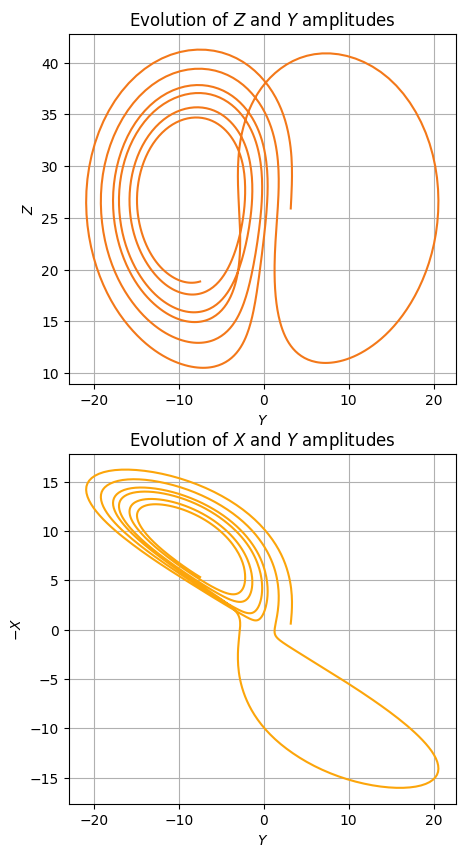

In [6]:
# Part 4, taking time span of [14, 19]
t4_1 = np.linspace(14, 19, 1000)
W = data.sol(t4_1)

fig, ax = plt.subplots(2, 1, dpi=100, figsize=(5, 10))

ax[0].plot(W[1], W[2], c=colours[7])

ax[1].plot(W[1], -W[0], c=colours[8])

ax[0].set_ylabel(r"$Z$")
ax[0].set_xlabel(r"$Y$")
ax[0].set_title(r'Evolution of $Z$ and $Y$ amplitudes')
ax[1].set_ylabel(r"$-X$")
ax[1].set_xlabel(r"$Y$")
ax[1].set_title(r'Evolution of $X$ and $Y$ amplitudes')
ax[0].grid()
ax[1].grid()

plt.show()

The reproductions are not exactly the same, and I had to invert the y-axis for the bottom graph to match the figures by Lorenz, but they are very similar in shape.

In [7]:
# Part 5
diff = (0, 1e-8, 0)
W0_1 = [a + b for a, b in zip(W0, diff)]
data5 = solve_ivp(get_derivatives, t_span=[0, 60], y0=W0_1, dense_output=True)

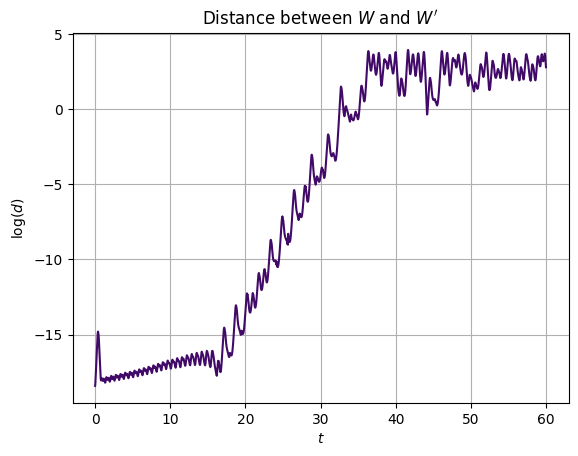

In [8]:
# I'll use a time array to compute the differences:
t5 = np.linspace(0, 60, 6000)
(xvals, yvals, zvals) = (data5.sol(t5)[i] - data.sol(t5)[i] for i in range(3))

distance = [((x ** 2 + y ** 2 + z ** 2) ** 0.5)
            for x, y, z in zip(xvals, yvals, zvals)]

plt.plot(t5, np.log(distance), c=colours[2])
plt.grid()
plt.xlabel(r'$t$')
plt.ylabel(r'$\log(d)$')
plt.title(r"Distance between $W$ and $W'$")
plt.show()